In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Função para calcular DPS
def calcular_dps(atk_base, atk_speed_percent, sharpness_level, base_aps=1.6):
    sharpness_bonus = 0.5 * sharpness_level + 1.0

    atk_efetivo = atk_base + sharpness_bonus

    #Fist base: +0.5 thanks MikeTheImpaler
    fist_bonus = 0.5
    atk_efetivo = atk_base + sharpness_bonus + fist_bonus

    multiplier = 1 + (atk_speed_percent / 100)
    aps = base_aps * multiplier
    dano_medio_por_hit = atk_efetivo * (5 / 3)  # 100% + 100% + 300% = 500% → média 166.67%
    dps_com_passiva = aps * dano_medio_por_hit
    dps_sem_passiva = aps * atk_efetivo
    boost_passiva = ((5/3) - 1) * 100           # 66.67%

    tempo_por_ataque = 1 / aps
    tempo_3_ataques = 3 / aps
    dano_3_ataques = atk_efetivo * 5

    return {
        "atk_base": atk_base,
        "sharpness_level": sharpness_level,
        "sharpness_bonus": round(sharpness_bonus, 2),
        "atk_efetivo": round(atk_efetivo, 2),
        "atk_speed": atk_speed_percent,
        "aps": round(aps, 3),
        "tempo_por_ataque": round(tempo_por_ataque, 4),
        "dano_medio_por_hit": round(dano_medio_por_hit, 2),
        "dps_com_passiva": round(dps_com_passiva, 2),
        "dps_sem_passiva": round(dps_sem_passiva, 2),
        "boost_passiva": f"{boost_passiva:.1f}%",
        "dano_em_3_ataques": round(dano_3_ataques, 2),
        "tempo_3_ataques": round(tempo_3_ataques, 4),
        "dps_ciclo": round(dano_3_ataques / tempo_3_ataques, 2)
    }

In [26]:
# Dados limpos
data = [
    {'sharp': 4, 'ad': 6.94, 'as': 133.21, 'mending': 0, 'price': 1500000},
    {'sharp': 4, 'ad': 6.7, 'as': 142.69, 'mending': 0, 'price': 1500000},
    {'sharp': 4, 'ad': 6.88, 'as': 130.56, 'mending': 0, 'price': 1200000},
    {'sharp': 4, 'ad': 6.95, 'as': 120.56, 'mending': 0, 'price': 1200000},
    {'sharp': 4, 'ad': 6.89, 'as': 127.33, 'mending': 0, 'price': 1100000},
    {'sharp': 5, 'ad': 5.86, 'as': 132.22, 'mending': 0, 'price': 670000},
    {'sharp': 4, 'ad': 6.55, 'as': 148.29, 'mending': 1, 'price': 3000000},
    {'sharp': 4, 'ad': 6.83, 'as': 128.38, 'mending': 1, 'price': 2250000},
    {'sharp': 5, 'ad': 6.0, 'as': 122.14, 'mending': 0, 'price': 1250000},
    {'sharp': 4, 'ad': 6.36, 'as': 146.13, 'mending': 0, 'price': 900000},
    {'sharp': 5, 'ad': 5.89, 'as': 122.67, 'mending': 0, 'price': 850000},
    {'sharp': 5, 'ad': 6.23, 'as': 129.71, 'mending': 0, 'price': 1200000},
    {'sharp': 4, 'ad': 6.6, 'as': 120.88, 'mending': 1, 'price': 1900000},
    {'sharp': 5, 'ad': 5.9, 'as': 149.08, 'mending': 0, 'price': 1500000},
    {'sharp': 4, 'ad': 6.25, 'as': 125.19, 'mending': 0, 'price': 650000},
    {'sharp': 4, 'ad': 6.59, 'as': 129.08, 'mending': 0, 'price': 1000000},
    {'sharp': 5, 'ad': 6.08, 'as': 147.43, 'mending': 0, 'price': 1200000},
    {'sharp': 4, 'ad': 5.82, 'as': 127.41, 'mending': 1, 'price': 1000000},
    {'sharp': 4, 'ad': 6.61, 'as': 131.73, 'mending': 1, 'price': 2000000},
    {'sharp': 5, 'ad': 5.12, 'as': 140.45, 'mending': 1, 'price': 1000000},
    {'sharp': 5, 'ad': 6.32, 'as': 140.14, 'mending': 1, 'price': 2500000},
    {'sharp': 4, 'ad': 6.27, 'as': 129.04, 'mending': 0, 'price': 800000},
    {'sharp': 5, 'ad': 6.88, 'as': 147.18, 'mending': 0, 'price': 5000000},
    {'sharp': 4, 'ad': 5.79, 'as': 134.55, 'mending': 1, 'price': 900000},
    {'sharp': 4, 'ad': 6.43, 'as': 123.55, 'mending': 0, 'price': 550000},
    {'sharp': 4, 'ad': 6.43, 'as': 126.55, 'mending': 0, 'price': 750000},
    {'sharp': 5, 'ad': 5.7, 'as': 143.49, 'mending': 0, 'price': 900000},
    {'sharp': 4, 'ad': 6.81, 'as': 132.66, 'mending': 0, 'price': 1200000},
    {'sharp': 5, 'ad': 6.24, 'as': 121.02, 'mending': 0, 'price': 800000},
    {'sharp': 4, 'ad': 5.71, 'as': 140.39, 'mending': 1, 'price': 900000},
    {'sharp': 4, 'ad': 6.9, 'as': 129.14, 'mending': 0, 'price': 1000000},
    {'sharp': 5, 'ad': 6.65, 'as': 127.93, 'mending': 0, 'price': 1200000},
    {'sharp': 5, 'ad': 6.82, 'as': 147.58, 'mending': 1, 'price': 8500000},
    {'sharp': 5, 'ad': 6.43, 'as': 140.38, 'mending': 1, 'price': 4500000},
    {'sharp': 5, 'ad': 6.45, 'as': 146.00, 'mending': 1, 'price': 6000000},
    {'sharp': 5, 'ad': 5.46, 'as': 127.89, 'mending': 1, 'price': 1000000},
    {'sharp': 4, 'ad': 6.27, 'as': 125.69, 'mending': 0, 'price': 570000},
    {'sharp': 5, 'ad': 6.65, 'as': 141.06, 'mending': 0, 'price': 2000000},
    {'sharp': 4, 'ad': 7.00, 'as': 147.34, 'mending': 0, 'price': 4500000},
    {'sharp': 5, 'ad': 6.61, 'as': 131.05, 'mending': 1, 'price': 2100000},
    {'sharp': 5, 'ad': 6.09, 'as': 137.25, 'mending': 0, 'price': 800000},
    {'sharp': 4, 'ad': 5.28, 'as': 134.85, 'mending': 1, 'price': 1200000},
    {'sharp': 5, 'ad': 6.09, 'as': 137.25, 'mending': 0, 'price': 800000},
    {'sharp': 4, 'ad': 5.28, 'as': 134.85, 'mending': 1, 'price': 1200000},
    {'sharp': 4, 'ad': 5.08, 'as': 132.7, 'mending': 1, 'price': 700000},
    {'sharp': 4, 'ad': 5.35, 'as': 142.5, 'mending': 1, 'price': 800000},
    {'sharp': 4, 'ad': 5.32, 'as': 139.2, 'mending': 0, 'price': 800000},
    {'sharp': 4, 'ad': 5.29, 'as': 129.2, 'mending': 0, 'price': 600000},
    {'sharp': 4, 'ad': 6.91, 'as': 128.3, 'mending': 1, 'price': 2750000},
    {'sharp': 4, 'ad': 5.84, 'as': 129.6, 'mending': 1, 'price': 850000},
    {'sharp': 4, 'ad': 6, 'as': 128.1, 'mending': 0, 'price': 750000},
    {'sharp': 5, 'ad': 5, 'as': 149.2, 'mending': 0, 'price': 550000},
    {'sharp': 4, 'ad': 6.02, 'as': 136.7, 'mending': 0, 'price': 800000},
    {'sharp': 4, 'ad': 6.96, 'as': 132, 'mending': 1, 'price': 2700000},
    {'sharp': 4, 'ad': 6.42, 'as': 132.8, 'mending': 0, 'price': 900000},
    {'sharp': 5, 'ad': 6.68, 'as': 136, 'mending': 1, 'price': 7000000},
    {'sharp': 5, 'ad': 6.68, 'as': 128, 'mending': 1, 'price': 7250000},
    {'sharp': 4, 'ad': 7, 'as': 138.09, 'mending': 0, 'price': 2500000},
    {'sharp': 5, 'ad': 6.72, 'as': 146.8, 'mending': 1, 'price': 8000000},


]

df = pd.DataFrame(data)

In [27]:
# Calcular DPS para cada item
df['dps'] = df.apply(lambda row: calcular_dps(row['ad'], row['as'], row['sharp'])['dps_com_passiva'], axis=1)

# Exibir a tabela com DPS
print("DATA:")
display(df)

# Preparar dados para treinamento (usando DPS e mending como features)
features = ['dps', 'mending']
X = df[features]
y = df['price']

# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsões e métricas
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"\nRMSE on the test set: {rmse:.2f}")

# Função para prever preço
def prever_preco(sharp, ad, as_, mending):
    dps = calcular_dps(ad, as_, sharp)['dps_com_passiva']
    new_item = pd.DataFrame({
        'dps': [dps],
        'mending': [1 if mending else 0]
    })
    predicted_price = model.predict(new_item)[0]
    print(f"Price Prediction: {predicted_price:.2f}")

# Widgets interativos
sharp_widget = widgets.IntSlider(min=4, max=5, step=1, value=4, description='Sharp:')
ad_widget = widgets.FloatText(value=6.5, description='AD:')
as_widget = widgets.FloatText(value=130.0, description='AS:')
mending_widget = widgets.Checkbox(value=False, description='Mending')

# Botão para prever
button = widgets.Button(description="Price Prediction")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        prever_preco(sharp_widget.value, ad_widget.value, as_widget.value, mending_widget.value)

button.on_click(on_button_clicked)

# Exibir interface
display(sharp_widget, ad_widget, as_widget, mending_widget, button, output)

DATA:


,sharp,ad,as,mending,price,dps
0,4,6.94,133.21,0,1500000,64.93
1,4,6.70,142.69,0,1500000,66.01
2,4,6.88,130.56,0,1200000,63.82
3,4,6.95,120.56,0,1200000,61.46
4,4,6.89,127.33,0,1100000,62.99
5,5,5.86,132.22,0,670000,61.06
6,4,6.55,148.29,1,3000000,66.54
7,4,6.83,128.38,1,2250000,62.91
8,5,6.00,122.14,0,1250000,59.24
9,4,6.36,146.13,0,900000,64.72



RMSE on the test set: 908160.57


IntSlider(value=4, description='Sharp:', max=5, min=4)

FloatText(value=6.5, description='AD:')

FloatText(value=130.0, description='AS:')

Checkbox(value=False, description='Mending')

Button(description='Price Prediction', style=ButtonStyle())

Output()

# Model Comparison
Let's compare the performance of different regression models for predicting prices.

COMPARAÇÃO DE MODELOS

Random Forest:
  RMSE (Treino):  $448,050.45
  RMSE (Teste):   $908,160.57
  MAE (Teste):    $513,241.67
  R² (Treino):    0.9510
  R² (Teste):     0.6069

Gradient Boosting:
  RMSE (Treino):  $54,014.69
  RMSE (Teste):   $1,299,499.76
  MAE (Teste):    $679,001.97
  R² (Treino):    0.9993
  R² (Teste):     0.1952

Ridge Regression:
  RMSE (Treino):  $1,134,178.64
  RMSE (Teste):   $846,323.61
  MAE (Teste):    $641,447.81
  R² (Treino):    0.6861
  R² (Teste):     0.6586

Linear Regression:
  RMSE (Treino):  $1,131,574.02
  RMSE (Teste):   $869,222.56
  MAE (Teste):    $659,862.26
  R² (Treino):    0.6875
  R² (Teste):     0.6399


Resumo das Métricas:


,RMSE Train,RMSE Test,MAE Test,R² Train,R² Test
Random Forest,4.480505e+05,9.081606e+05,513241.666667,0.951009,0.606929
Gradient Boosting,5.401469e+04,1.299500e+06,679001.967270,0.999288,0.195181
Ridge Regression,1.134179e+06,8.463236e+05,641447.814541,0.686075,0.658635
Linear Regression,1.131574e+06,8.692226e+05,659862.259373,0.687516,0.639913


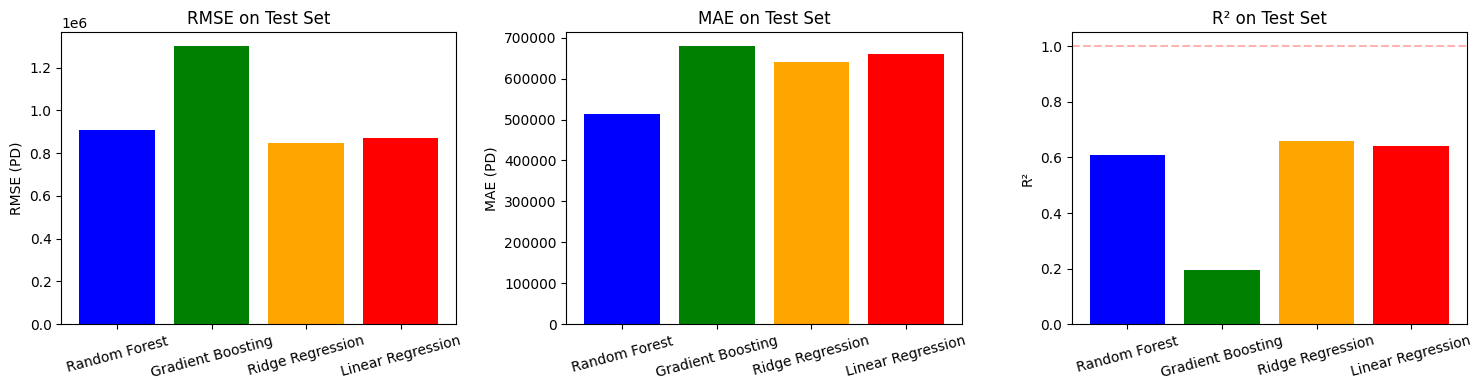

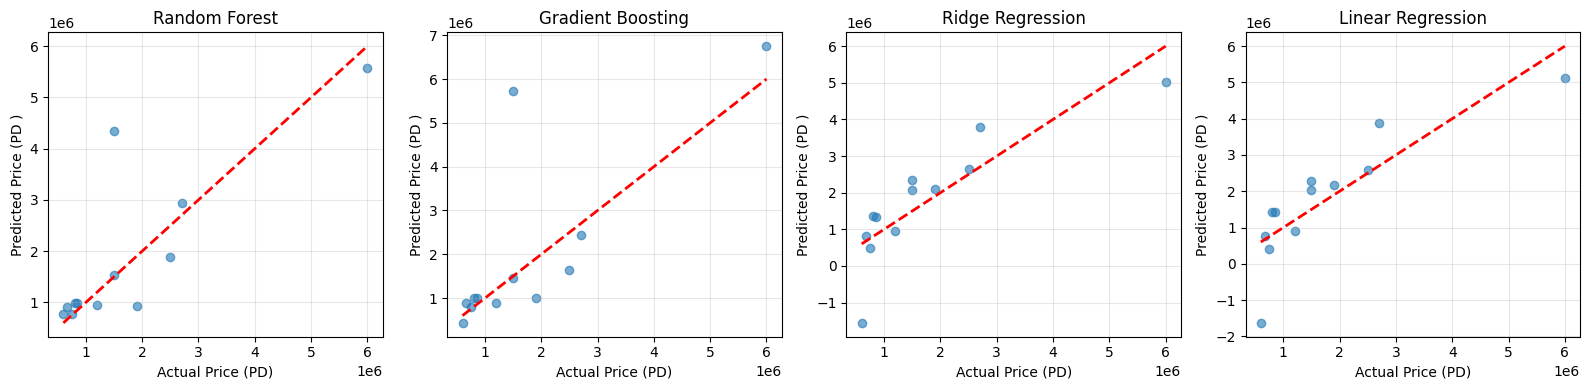


 MELHOR MODELO: Ridge Regression
   RMSE: $846,323.61
   R²: 0.6586


In [28]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Preparar dados
features = ['dps', 'mending']
X = df[features]
y = df['price']

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos para comparar
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Linear Regression': LinearRegression()
}

# Treinar e avaliar cada modelo
results = {}
predictions = {}

print("="*70)
print("COMPARAÇÃO DE MODELOS")
print("="*70)

for name, model in models.items():
    # Treinar
    model.fit(X_train, y_train)
    
    # Prever
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calcular métricas
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    results[name] = {
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'MAE Test': mae_test,
        'R² Train': r2_train,
        'R² Test': r2_test
    }
    
    predictions[name] = y_pred_test
    
    print(f"\n{name}:")
    print(f"  RMSE (Treino):  ${rmse_train:,.2f}")
    print(f"  RMSE (Teste):   ${rmse_test:,.2f}")
    print(f"  MAE (Teste):    ${mae_test:,.2f}")
    print(f"  R² (Treino):    {r2_train:.4f}")
    print(f"  R² (Teste):     {r2_test:.4f}")

print("\n" + "="*70)

# Criar DataFrame com resultados para visualização
results_df = pd.DataFrame(results).T
print("\nResumo das Métricas:")
display(results_df)

# RMSE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(results.keys(), [v['RMSE Test'] for v in results.values()], color=['blue', 'green', 'orange', 'red'])
axes[0].set_ylabel('RMSE (PD)')
axes[0].set_title('RMSE on Test Set')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results.keys(), [v['MAE Test'] for v in results.values()], color=['blue', 'green', 'orange', 'red'])
axes[1].set_ylabel('MAE (PD)')
axes[1].set_title('MAE on Test Set')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results.keys(), [v['R² Test'] for v in results.values()], color=['blue', 'green', 'orange', 'red'])
axes[2].set_ylabel('R²')
axes[2].set_title('R² on Test Set')
axes[2].axhline(y=1.0, color='r', linestyle='--', alpha=0.3)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
plt.figure(figsize=(16, 4))

for i, (name, y_pred) in enumerate(predictions.items(), 1):
    plt.subplot(1, 4, i)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price (PD)')
    plt.ylabel('Predicted Price (PD )')
    plt.title(f'{name}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# melhor modelo
best_model_name = min(results, key=lambda x: results[x]['RMSE Test'])
print(f"\n MELHOR MODELO: {best_model_name}")
print(f"   RMSE: ${results[best_model_name]['RMSE Test']:,.2f}")
print(f"   R²: {results[best_model_name]['R² Test']:.4f}")

# Interactive Model Comparator
Use the interface below to test predictions with all models simultaneously.

In [ ]:
# Função para comparar previsões de todos os modelos
def comparar_modelos(sharp, ad, as_, mending):
    dps = calcular_dps(ad, as_, sharp)['dps_com_passiva']
    new_item = pd.DataFrame({
        'dps': [dps],
        'mending': [1 if mending else 0]
    })
    
    print("="*60)
    print(f"COMPARISON")
    print("="*60)
    print(f"Sharp: {sharp} | AD: {ad} | AS: {as_}% | Mending: {'Sim' if mending else 'Não'}")
    print(f"DPS: {dps:.2f}")
    print("-"*60)
    
    previsoes = {}
    for name, model in models.items():
        predicted_price = model.predict(new_item)[0]
        previsoes[name] = predicted_price
        print(f"{name:20s}: PD {predicted_price:,.2f}")
    
    print("-"*60)
    media = np.mean(list(previsoes.values()))
    std = np.std(list(previsoes.values()))
    print(f"{'Média':20s}: PD {media:,.2f}")
    print(f"{'Desvio Padrão':20s}: PD {std:,.2f}")
    print("="*60)
    
    # Gráfico de comparação
    plt.figure(figsize=(10, 5))
    bars = plt.bar(previsoes.keys(), previsoes.values(), color=['blue', 'green', 'orange', 'red'])
    plt.axhline(y=media, color='purple', linestyle='--', label=f'Average: PD {media:,.0f}')
    plt.ylabel('Predicted Price (PD)')
    plt.title('Model Predictions Comparison')
    plt.xticks(rotation=15)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'PD {height:,.0f}',
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

sharp_widget2 = widgets.IntSlider(min=4, max=5, step=1, value=5, description='Sharp:')
ad_widget2 = widgets.FloatText(value=6.5, description='AD:')
as_widget2 = widgets.FloatText(value=140.0, description='AS:')
mending_widget2 = widgets.Checkbox(value=True, description='Mending')

button2 = widgets.Button(description="Model Predictions Comparison", button_style='success')
output2 = widgets.Output()

def on_button_clicked2(b):
    with output2:
        output2.clear_output()
        comparar_modelos(sharp_widget2.value, ad_widget2.value, as_widget2.value, mending_widget2.value)

button2.on_click(on_button_clicked2)

display(sharp_widget2, ad_widget2, as_widget2, mending_widget2, button2, output2)

IntSlider(value=5, description='Sharp:', max=5, min=4)

FloatText(value=6.5, description='AD:')

FloatText(value=140.0, description='AS:')

Checkbox(value=True, description='Mending')

Button(button_style='success', description='Comparar Modelos', style=ButtonStyle())

Output()